In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.transforms as ekt
import earthkit.geo as ekg
from earthkit.meteo import thermo, wind # this import is not like the others... because it doesn't work if it is...
import earthkit.hydro as ekh
import numpy as np

# Basic Idea

Conduct an analysis of the water balance for a catchment where we also have observations.

Basic idea: water balance equation

$ P = Q + ET \pm \Delta S$

Precipitation = Runoff + Evapotranspiration + Changes in Storage

Investigate this relationship for some of our data.
- earthkit-data to load data from CDS
- earthkit-geo to regrid onto a river network grid
- earthkit-hydro to do catchment averaging
- earthkit-transforms to do temporal aggregations to daily
- earthkit-meteo to help compute evaporation (note: variable is actually available directly, but this is to show off earthkit)
- earthkit-plots for pretty visualisations

# earthkit-data

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
</div>

In [2]:
YEARS  = ["2025"]
MONTHS = [f"{m:02d}" for m in range(5, 6)]
DAYS   = [f"{d:02d}" for d in range(1, 10)]   # CDS ignores days that don't exist in the month

CDS_REQUEST = dict(
    product_type="reanalysis",
    grid=[1, 1],
    year=YEARS,
    month=MONTHS,
    day=DAYS,
    time=[f"{h:02d}:00" for h in range(24)],
    variable=[
        "2m_temperature",                # t2m  – K
        "2m_dewpoint_temperature",       # d2m  – K
        "10m_u_component_of_wind",       # u10  – m/s
        "10m_v_component_of_wind",       # v10  – m/s
        "surface_net_solar_radiation",   # ssr – J/m² accumulated per step
        "surface_net_thermal_radiation", # str – J/m² accumulated per step
        "evaporation",                   # e – m accumulated per step
        "total_precipitation",           # tp – m accumulated per step
    ],
)

# this takes 6 mins so we might want to reduce
ds = ekd.from_source("cds", "reanalysis-era5-single-levels", request=CDS_REQUEST)

In [3]:
ds_fieldlist = ds.to_fieldlist()

# earthkit-plots

<div align="center">
  <br>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a> 
</div>

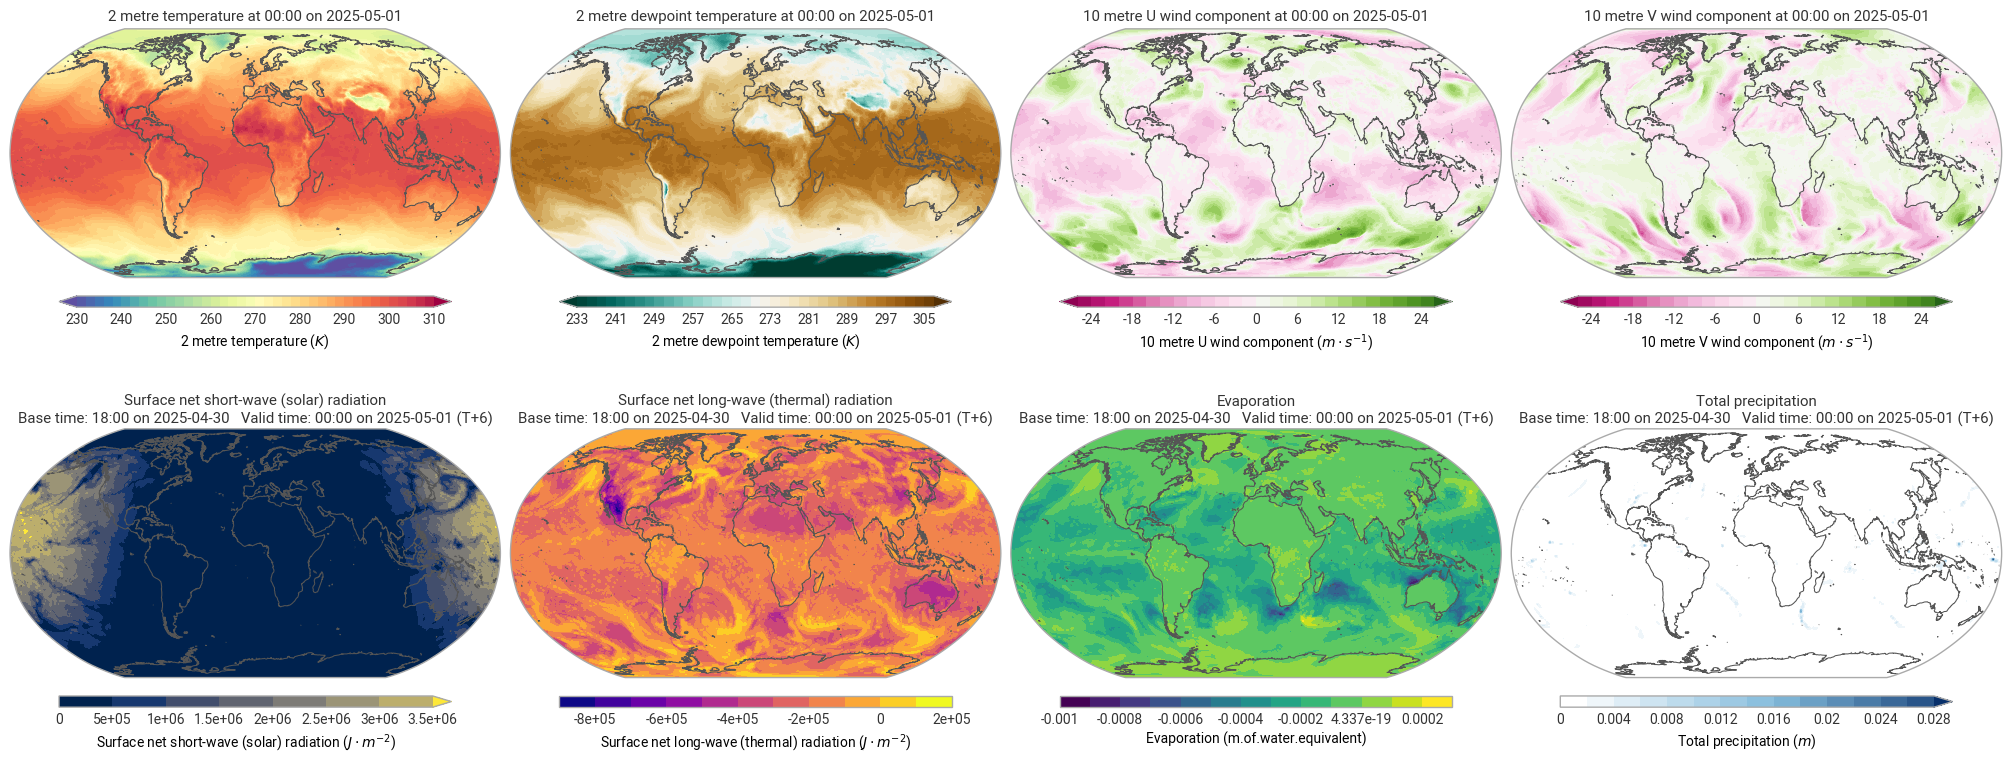

In [4]:
ekp.geo.plot(ds_fieldlist.sel({"time.valid_datetime": "2025-05-01"}), crs="Robinson")

# earthkit-geo

<div align="center">
  <br>
  <a href="https://earthkit-geo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-geo-light.svg" alt="earthkit-geo" width="200">
  </a>
</div>

In [5]:
gridspec = {
        'grid': [15/60, 15/60],
        'area': [
            89.875,
            -179.875,
            -89.875,
            179.875
            ]
        }

In [6]:
fields = []
for field in ds_fieldlist:
    # conservative interpolation
    if field.get("parameter.variable") in ["e", "ssr", 'str', 'tp']:
        regrided_field = ekg.regrid(field, gridspec, interpolation="grid-box-average")
    # linear interpolation
    else:
        regrided_field = ekg.regrid(field, gridspec, interpolation="linear")
    fields.append(regrided_field)

ds_cama_15min = ekd.FieldList.from_fields(fields)

In [7]:
xr_ds = ds_cama_15min.to_xarray(time_dims=["valid_time"])

# earthkit-transforms

<div align="center">
  <br>
  <a href="https://earthkit-transforms.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-transforms-light.svg" alt="earthkit-transforms" width="200">
  </a>
</div>

In [8]:
daily_avg_ds = ekt.temporal.daily_mean(xr_ds)
daily_max_2t = ekt.temporal.daily_max(daily_avg_ds["2t"])
daily_min_2t = ekt.temporal.daily_min(daily_avg_ds["2t"])

daily_ds = daily_avg_ds
daily_ds["2t_max"] = daily_max_2t
daily_ds["2t_min"] = daily_min_2t
daily_ds["R_n"] = ekt.temporal.daily_sum(xr_ds["ssr"] + xr_ds["str"])
daily_ds

<xarray.Dataset> Size: 821MB
Dimensions:     (valid_time: 9, latitude: 720, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 72B 2025-05-01 ... 2025-05-09
  * latitude    (latitude) float64 6kB 89.88 89.62 89.38 ... -89.62 -89.88
  * longitude   (longitude) float64 12kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    10u         (valid_time, latitude, longitude) float64 75MB 6.225 ... 3.519
    10v         (valid_time, latitude, longitude) float64 75MB 7.632 ... 2.774
    2d          (valid_time, latitude, longitude) float64 75MB 263.2 ... 220.1
    2t          (valid_time, latitude, longitude) float64 75MB 265.2 ... 223.7
    e           (valid_time, latitude, longitude) float64 75MB -1.202e-05 ......
    ssr         (valid_time, latitude, longitude) float64 75MB 1.049e+05 ... ...
    str         (valid_time, latitude, longitude) float64 75MB -8.9e+04 ... -...
    tp          (valid_time, latitude, longitude) float64 75MB 7.133e-06 ... ...
    2t_max      (valid_time, latitude, longitude) float64 75MB 265.2 ... 223.7
    2t_min      (valid_time, latitude, longitude) float64 75MB 265.2 ... 223.7
    R_n         (valid_time, latitude, longitude) float64 75MB 3.808e+05 ... ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

# earthkit-meteo

<div align="center">
  <br>
  <a href="https://earthkit-meteo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-meteo-light.svg" alt="earthkit-meteo" width="200">
  </a>
</div>


**Reference Evapotranspiration (ET₀) via Penman–Monteith (FAO-56)**

This notebook computes **daily reference evapotranspiration ET₀** for the Rhine
catchment at Basel using the **FAO-56 Penman–Monteith** equation and ERA5 hourly
meteorological fields.

Source: https://appgeodb.nancy.inrae.fr/biljou/pdf/Allen_FAO1998.pdf

## Equations

**FAO-56 Penman–Monteith equation**

$$
ET_0 = \frac{0.408\,\Delta\,(R_n - G)
       + \gamma\,\frac{900}{T}\,u_2\,\delta e}
      {\Delta + \gamma\,(1 + 0.34\,u_2)}
\quad [\text{mm day}^{-1}]
$$

Quantities:
- $ET_0$ = Reference evapotranspiration, Water volume evapotranspired (mm/day)
- $\Delta$ = Rate of change of saturation specific humidity with air temperature. (Pa/K)
- $R_n$ = Net irradiance (MJ/m^2/day), the external source of energy flux
- $G$ = Ground heat flux (MJ/m^2/day), usually equivalent to zero on a day
- $T$ = Air temperature at 2m (K)
- $u_2$ = Wind speed at 2m height (m/s)
- $\delta e = (e_s - e_a)$ = vapor pressure deficit (kPa)
- $\gamma$ = Psychrometric constant (γ ≈ 66 Pa/K)

**FAO wind speed (logarithmic profile)**
$$
u_2 = u_z \frac{4.87}{\ln(67.8 z - 5.42)}
$$
We use with `z=10`.

- $z$ = Height of measurement above ground surface (m)
- $u_z$ = Wind speed at $z$m above ground surface (m/s)

**FAO Mean saturation vapour pressure**
$$
e_s = 0.5\left[e(T_{max}) + e(T_{min})\right]
$$

**Actual vapour pressure (ea) derived from dewpoint temperature**
$$
e_a = e(T_{dew})
$$

> **Note:** ET₀ represents the evaporative demand of the atmosphere for a hypothetical
> well-watered reference grass canopy.  It differs from *actual* evapotranspiration,
> which is limited by soil moisture and canopy resistance.

In [9]:
T = daily_ds["2t"] # K
gamma = 66 # approximately constant, 66 Pa/K
u_10 = wind.speed(daily_ds["10u"], daily_ds["10v"]) # m/s
u_2 = u_10 * 4.87 / np.log(67.8 * 10 - 5.42) # m/s, using logarithmic wind profile to estimate 2m wind speed from 10m wind speed
delta = thermo.saturation_vapour_pressure_slope(daily_ds["2t"]) # Pa/K
R_n = daily_ds["R_n"] * 1e-6 # convert from J/m^2 to MJ/m^2 (summed over day)
G = 0 # MJ/m^2, assuming negligible ground heat flux, valid approximation only for daily steps

e_Tmax = thermo.saturation_vapour_pressure(daily_ds["2t_max"]) / 1000 # kPa
e_Tmin = thermo.saturation_vapour_pressure(daily_ds["2t_min"]) / 1000 # kPa
e_s = 0.5 * (e_Tmax + e_Tmin) / 1000 # kPa, average saturation vapour pressure
e_a = thermo.saturation_vapour_pressure(daily_ds["2d"]) / 1000 # kPa, actual vapour pressure from dew point temperature
delta_e = (e_s - e_a) # kPa

et_fao = ( 0.408 * delta * (R_n - G) + gamma * (900 / T) * u_2 * delta_e ) / ( delta + gamma * (1 + 0.34 * u_2) ) # mm/day

In [10]:
water_balance_ds = daily_ds[['tp', 'e']]
water_balance_ds['e_fao'] = et_fao # mm/day already
water_balance_ds['e'] = water_balance_ds['e'] * 1000 * 24 # convert from m/h to mm/day
water_balance_ds['tp'] = water_balance_ds['tp'] * 1000 * 24 # convert from m/h to mm/day
water_balance_ds

<xarray.Dataset> Size: 224MB
Dimensions:     (valid_time: 9, latitude: 720, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 72B 2025-05-01 ... 2025-05-09
  * latitude    (latitude) float64 6kB 89.88 89.62 89.38 ... -89.62 -89.88
  * longitude   (longitude) float64 12kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    tp          (valid_time, latitude, longitude) float64 75MB 0.1712 ... 0.155
    e           (valid_time, latitude, longitude) float64 75MB -0.2886 ... 0....
    e_fao       (valid_time, latitude, longitude) float64 75MB -1.69 ... -0.0...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

# earthkit-hydro

<div align="center">
  <br>
  <a href="https://earthkit-hydro.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-hydro-light.svg" alt="earthkit-hydro" width="200">
  </a>
</div>

In [11]:
net = ekh.river_network.load("cama_15min", "4", use_cache=False)

Cache disabled.


In [12]:
locations = {
    "Rhine at Basel": (47.56, 7.59)
    }
catchment_averaged_ds = ekh.catchments.mean(net, water_balance_ds, locations)

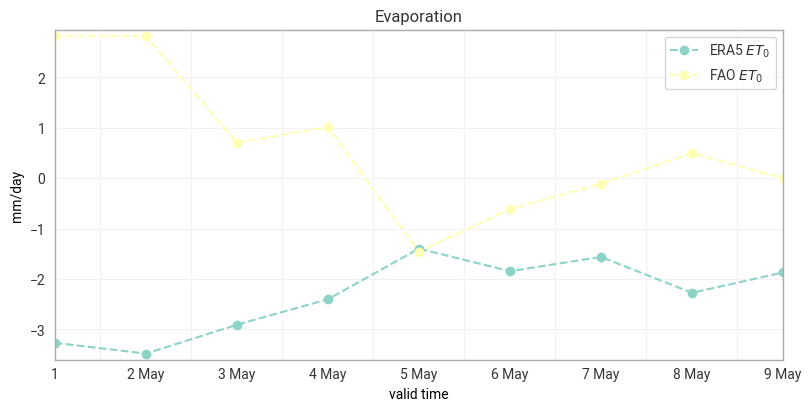

In [13]:
ekp.timeseries.line(
        catchment_averaged_ds['e'], linestyle='--', marker='o', label="ERA5 $ET_0$", time_offset="12h"
    ).line(
        catchment_averaged_ds['e_fao'], linestyle='--', marker='o', label="FAO $ET_0$", time_offset="12h"
    ).ylabel(
        "mm/day"
    ).title(
        "Evaporation"
    ).xticks(frequency="D", period=True, format="%-d %b").legend().show()

# get some observations🇨🇭!

In [14]:
# source1: https://www.hydrodaten.admin.ch/de/seen-und-fluesse/stationen-und-daten/2289 (has catchment area)
# source2: https://data.bs.ch/explore/dataset/100089 (data itself)

from urllib.parse import urlencode

DATE_FROM = "2025-05-01"     # inclusive
DATE_TO   = "2025-05-10"     # exclusive  →  full year 2025

BASE_URL  = "https://data.bs.ch/api/explore/v2.1/catalog/datasets/100089"
CSV_URL   = BASE_URL + "/exports/csv"

params = {
    "where": f"timestamp >= '{DATE_FROM}' AND timestamp < '{DATE_TO}'",
    "order_by": "timestamp asc",
    "limit": -1,          # return all matching records
    "delimiter": ";",
}
url = CSV_URL + "?" + urlencode(params)

In [15]:
df = ekd.from_source("url", url).to_pandas(pandas_read_csv_kwargs={"delimiter": ";", "parse_dates": ["timestamp"], "index_col": "timestamp"}).resample('D').mean()
df['abfluss'] # in m^3 s^-1

df["depth"] = df["abfluss"] * 60*60*24 / 35878 * 1e-6 * 1000 # convert from m^3/s to mm/day, using the catchment area (35878 km^2)

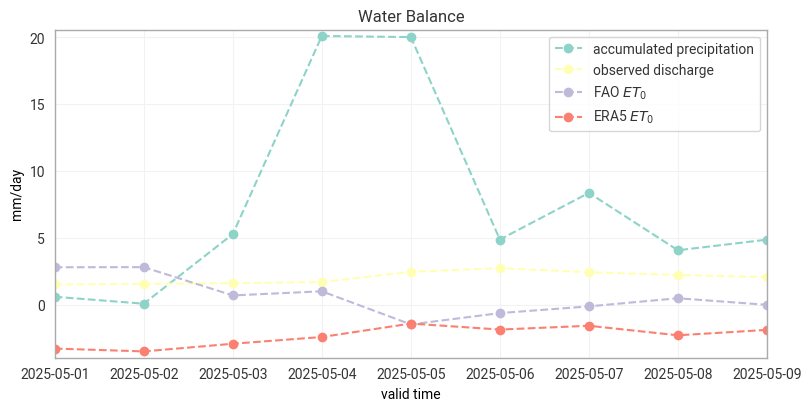

In [16]:
ekp.timeseries.line(
        catchment_averaged_ds['tp'], linestyle='--', marker='o', label="accumulated precipitation"
    ).line(
        x=df['depth'].index, data=df['depth'].values, linestyle='--', marker='o', label="observed discharge"
    ).line(
        catchment_averaged_ds['e_fao'], linestyle='--', marker='o', label="FAO $ET_0$"
    ).line(
        catchment_averaged_ds['e'], linestyle='--', marker='o', label="ERA5 $ET_0$"
    ).ylabel(
        "mm/day"
    ).title(
        "Water Balance"
    ).legend().show()